In [1]:
from pathlib import Path
import duckdb
import plotly.express as px

ROOT = Path(r"D:\Driveguard")
DATA = (ROOT / "data" / "processed").as_posix() + "/*.parquet"

con = duckdb.connect()
con.execute(f"CREATE VIEW drives AS SELECT * FROM read_parquet('{DATA}')")

In [2]:
con.sql("""
SELECT MIN(date) AS first_day, MAX(date) AS last_day,
       COUNT(*) AS rows,
       COUNT(DISTINCT serial_number) AS drives,
       SUM(failure) AS failures
FROM drives
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,first_day,last_day,rows,drives,failures
0,2025-07-01,2026-06-30,123351646,365976,4751.0


In [3]:
afr = con.sql("""
SELECT model,
       COUNT(DISTINCT serial_number) AS drives,
       COUNT(*) AS drive_days,
       SUM(failure) AS failures,
       ROUND(SUM(failure) * 365.0 / COUNT(*) * 100, 2) AS afr_pct
FROM drives
GROUP BY model
HAVING COUNT(DISTINCT serial_number) >= 2000
ORDER BY drives DESC
""").df()
afr

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,model,drives,drive_days,failures,afr_pct
0,WDC WUH722222ALE6L4,45791,15640017,180.0,0.42
1,TOSHIBA MG08ACA16TA,40201,14519822,357.0,0.90
2,TOSHIBA MG07ACA14TA,37463,13581233,465.0,1.25
3,ST16000NM001G,35271,12534386,193.0,0.56
4,WDC WUH721816ALE6L4,26466,9600639,238.0,0.90
5,TOSHIBA MG10ACA20TE,25364,6855041,155.0,0.83
6,ST12000NM0008,18902,6780030,518.0,2.79
7,HGST HUH721212ALE604,13438,4822461,346.0,2.62
8,ST8000NM0055,13351,4796428,260.0,1.98
9,ST12000NM001G,13279,4813393,139.0,1.05


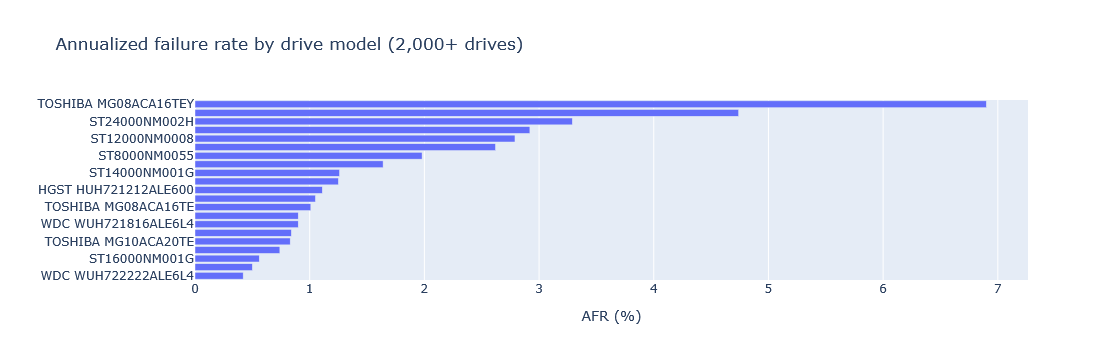

In [4]:
fig = px.bar(afr.sort_values("afr_pct"), x="afr_pct", y="model", orientation="h",
             title="Annualized failure rate by drive model (2,000+ drives)",
             labels={"afr_pct": "AFR (%)", "model": ""})
fig.show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

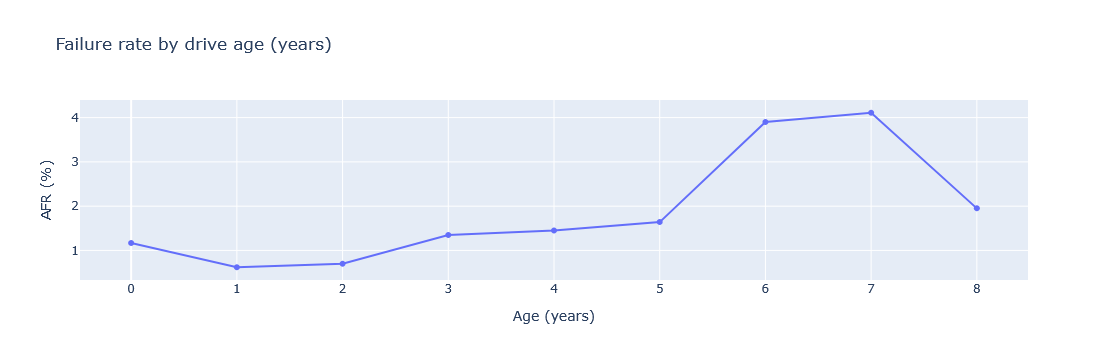

In [5]:
age = con.sql("""
SELECT FLOOR(smart_9_raw / 8760) AS age_years,
       COUNT(*) AS drive_days,
       SUM(failure) AS failures,
       ROUND(SUM(failure) * 365.0 / COUNT(*) * 100, 2) AS afr_pct
FROM drives
WHERE smart_9_raw IS NOT NULL
GROUP BY 1
HAVING COUNT(*) > 100000
ORDER BY 1
""").df()

px.line(age, x="age_years", y="afr_pct", markers=True,
        title="Failure rate by drive age (years)",
        labels={"age_years": "Age (years)", "afr_pct": "AFR (%)"})

In [6]:
con.sql("""
SELECT CASE WHEN failure = 1 THEN 'Failed that day' ELSE 'Healthy' END AS status,
       COUNT(*) AS rows,
       ROUND(AVG(CASE WHEN smart_5_raw   > 0 THEN 1 ELSE 0 END) * 100, 1) AS pct_bad_sectors_5,
       ROUND(AVG(CASE WHEN smart_187_raw > 0 THEN 1 ELSE 0 END) * 100, 1) AS pct_uncorrectable_187,
       ROUND(AVG(CASE WHEN smart_197_raw > 0 THEN 1 ELSE 0 END) * 100, 1) AS pct_pending_197,
       ROUND(AVG(CASE WHEN smart_198_raw > 0 THEN 1 ELSE 0 END) * 100, 1) AS pct_offline_198
FROM drives
GROUP BY 1
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,status,rows,pct_bad_sectors_5,pct_uncorrectable_187,pct_pending_197,pct_offline_198
0,Failed that day,4751,60.4,28.8,58.2,42.9
1,Healthy,123346895,5.0,1.5,1.9,1.3
